In [1]:
import pandas as pd
import ray
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import plotly.graph_objects as go
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                    StratifiedKFold, StratifiedShuffleSplit,
                                    cross_val_score)
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, classification_report
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.metrics import geometric_mean_score, make_index_balanced_accuracy
import numpy as np
import joblib
from pandarallel import pandarallel
from sklearn.preprocessing import LabelEncoder, StandardScaler
import re
import math
import os
from sklearn.metrics import make_scorer, average_precision_score
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.cluster import KMeans


from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)


2025-06-02 17:10:03.901720: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-02 17:10:03.903779: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 17:10:03.936075: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-02 17:10:03.936094: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-02 17:10:03.936116: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [2]:
def optimize_hyperparameters(X, y):
    # Initialize a BalancedRandomForestClassifier
    clf = BalancedRandomForestClassifier(replacement=True)

    # Define hyperparameters grid
    param_grid = {
        'n_estimators': [500,800,1200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'sampling_strategy': ['majority','not majority','all']
    }

    # Set up k-fold cross-validation
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    alpha = 0.1
    geo_mean = make_index_balanced_accuracy(alpha=alpha, squared=True)(geometric_mean_score)
    gmean = make_scorer(geo_mean, average='weighted')
    # Función que inverte el primer y segundo argumento para adaptarse al formato de `make_scorer`
        
    # Grid search with cross-validation
    grid_search = GridSearchCV(clf, param_grid, cv=kfold, scoring=gmean, n_jobs=-1, verbose=1)
    grid_search.fit(X, y)
    return grid_search

def preprocess_features(data,columns,bad_values):
    """
    Realiza el preprocesamiento de las características especificadas.

    Args:
    - data (pd.DataFrame): DataFrame original con los datos.

    Returns:
    - data (pd.DataFrame): DataFrame procesado con características adicionales y filas inválidas eliminadas.
    """
    
    # Busca valores 999 o -999 en las columnas especificadas
    invalid_values = data[columns].isin([bad_values, -bad_values]).sum()

    # Filtra y muestra solo las columnas que tienen estos valores inválidos
    columns_with_invalids = invalid_values[invalid_values > 0]

    if columns_with_invalids.empty:
        print(f" Todas las columnas tienen datos válidos, sin valores {bad_values} o -{bad_values}.")
    else:
        print(f"Las siguientes columnas tienen valores {bad_values} o -{bad_values}:\n{columns_with_invalids}")

    # Filtra el DataFrame para excluir filas con valores 999 o -999 en las columnas especificadas
    data = data[~data[columns].isin([bad_values, -bad_values]).any(axis=1)].reset_index(drop=True)

    return data

In [3]:
ray.init()

@ray.remote
def parallel_function(train_index, test_index, iteration, X, y, best_params):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    best_params['replacement'] = True
    best_brfc = BalancedRandomForestClassifier(**best_params)
    best_brfc.fit(X_train, y_train)
    y_proba = best_brfc.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva
    y_pred = np.where(y_proba > 0.6, 1, 0)
    
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    array_2,_ = C_M(y_test, y_proba)
    
    results = []
    classes = list(set(y_test))
    for cls, precision, recall, f1 in zip(classes, precision_per_class, recall_per_class, f1_per_class):
        results.append({
            'Iteration': iteration,
            'Class': cls,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })
    return array_2, results

def C_M(label,predict_label):
    predict_label = np.where(predict_label > 0.6, 1, 0)
    array = confusion_matrix(label, predict_label)
    df = pd.DataFrame(array)
    perc = df.copy()
    cols = perc.columns.values
    perc[cols] = perc[cols].div(perc[cols].sum(axis=1), axis=0).multiply(100)
    annot = df.round(2).astype(str) + "\n" + perc.round(1).astype(str) + "%"
    return array, annot


2025-06-02 17:10:07,277	INFO worker.py:1673 -- Started a local Ray instance.


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

class DataFrameScaler:
    def __init__(self):
        self.scalers = {}

    def scale(self, df):
        """
        Escala las columnas del DataFrame a media 0 y desviación estándar 1.
        """
        scaled_df = df.copy()
        for column in df.columns:
            scaler = StandardScaler()
            scaled_df[column] = scaler.fit_transform(df[column].values.reshape(-1, 1)).flatten()
            self.scalers[column] = scaler
        return scaled_df

    def inverse_scale(self, df):
        """
        Devuelve el DataFrame escalado a su estado original.
        """
        original_df = df.copy()
        for column in df.columns:
            scaler = self.scalers.get(column)
            if scaler:
                original_df[column] = scaler.inverse_transform(df[column].values.reshape(-1, 1)).flatten()
        return original_df

from itertools import combinations

def create_color_columns(mag_features, df):
    """
    Crea columnas de colores en el DataFrame df basadas en las combinaciones de mag_features.
    
    Parámetros:
    - mag_features: Lista de características para hacer combinaciones y crear colores.
    - df: DataFrame donde se añadirán las nuevas columnas de colores.
    
    Retorna:
    - df: DataFrame modificado con las nuevas columnas de colores.
    - colors: Lista de los nombres de las nuevas columnas de colores.
    """
    colors = []
    for v in combinations(mag_features, 2):
        df[f"{v[0]}-{v[1]}"] = df[v[0]] - df[v[1]]
        colors.append(f"{v[0]}-{v[1]}")
    return df, colors

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import math

def plot_confusion_matrix(CM_array, CM_std, labels, path='/home/marcelo/nico/MasivasData/Confusion_matrix_skiff_rf.pdf'):
    """
    Función para graficar una matriz de confusión con errores estándar, usando colores personalizados.
    
    Parámetros:
    - CM_array: Matriz de confusión.
    - CM_std: Matriz de errores estándar.
    - labels: Etiquetas de las clases.
    - path: Ruta para guardar la figura.
    """
    # Calcular el factor de escala
    factor = math.sqrt(10**2 + 8**2) / math.sqrt(6**2 + 4**2)

    # Convertir la matriz de confusión a porcentaje
    CM_percentage = CM_array / CM_array.sum(axis=1)[:, None] * 100
    CM_std_percentage = CM_std / CM_array.sum(axis=1)[:, None] * 100

    # Ajustar el tamaño de la fuente
    base_fontsize = 14
    adjusted_fontsize = int(base_fontsize * factor)

    # Crear un array con las anotaciones que incluyen el error
    annotations = np.array([
        [f"{CM_percentage[i, j]:.2f} ± {CM_std_percentage[i, j]:.2f}%" for j in range(CM_percentage.shape[1])]
        for i in range(CM_percentage.shape[0])
    ])

    # Definir colores personalizados
    colorblind_palette = sns.color_palette("colorblind", 4)
    colores = [colorblind_palette[1], colorblind_palette[2], colorblind_palette[3], colorblind_palette[0]]

    # Crear el colormap discreto
    cmap_discreto = ListedColormap(colores)

    # Crear una matriz de índices de colores
    indices_colores = np.array([[0, 1],  # Azul, rojo
                                [2, 3]]) # Naranja, verde

    # Crear el heatmap con colores personalizados
    plt.figure(figsize=(7, 7))
    ax = sns.heatmap(indices_colores, cmap=cmap_discreto, cbar=False, square=True,
                      annot_kws={"size": 16},
                     linewidths=1, annot=annotations, fmt='', 
                     xticklabels=labels, yticklabels=labels)

    # Cambiar el color del texto en las celdas a blanco
    for text in ax.texts:
        text.set_color('white')

    # Configuración de etiquetas
    plt.xlabel("Predicted Label", fontsize=20)
    plt.ylabel("True Label", fontsize=20)
    plt.xticks(rotation=0, fontsize=20)
    plt.yticks(fontsize=20)

    # Guardar y mostrar la figura
    plt.savefig(path, format='pdf', bbox_inches='tight')
    plt.show()


In [6]:

def plot_barplot(df, probability_col, label_col, bins, plot_type='mean_std'):
    plt.figure(figsize=(15, 6))

    # Utiliza pd.cut para categorizar los datos en los bins definidos
    df['Categoria'] = pd.cut(df[label_col], bins=bins, include_lowest=True, right=False)

    if plot_type == 'mean_std':
        # Calcula el promedio y la desviación estándar de la columna de probabilidad para cada categoría
        estadisticas = df.groupby('Categoria')[probability_col].agg(['mean', 'std'])

        # Crea el bar plot con el promedio y la desviación estándar
        plt.bar(estadisticas.index.astype(str), estadisticas['mean'], 
                yerr=estadisticas['std'], capsize=5, edgecolor='black')
        plt.ylabel('Promedio de Probabilidades (%)')

    elif plot_type == 'count':
        # Calcula la cuenta de cada categoría
        counts = df['Categoria'].value_counts().sort_index()

        # Convierte las cuentas a porcentaje del total
        counts_percentage = (counts / counts.sum()) * 100

        # Crea el bar plot con la cuenta de los bines en porcentaje
        plt.bar(counts_percentage.index.astype(str), counts_percentage, edgecolor='black')
        plt.ylabel('Porcentaje del Total (%)')

    plt.xlabel('Intervalos')
    plt.title(f'Bar Plot de {probability_col}')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

def plot_precision_recall(df,path_name):
    # Crear subconjuntos de datos
    df_test = df.loc[df['B2_cut_split'] == 'test']
    # Calcular Precision-Recall para el DataFrame completo
    precision, recall, thresholds = precision_recall_curve(df_test['B2'], df_test['B2_cut_probability'])
    print(len(recall))
    thresholds = np.append(thresholds, 1)
    return precision,recall,thresholds
    





In [7]:
def plot_contour(dataframe, column_x, column_y,bins,last_contour=False, ax=None):
    # Crear la figura y el eje si no se proporciona uno
    if ax is None:
        fig, ax = plt.subplots()

    # Extraer los datos de las columnas especificadas
    x = dataframe[column_x]
    y = dataframe[column_y]

    # Crear un histograma bidimensional
    x_bins = np.linspace(x.min(), x.max(),bins)  # Ajusta el número de bins según sea necesario
    y_bins = np.linspace(y.min(), y.max(), bins)  # Ajusta el número de bins según sea necesario
    H, x_edges, y_edges = np.histogram2d(x, y, bins=(x_bins, y_bins))

    # Convertir el histograma a densidades
    H = H.T  # Transponer para corregir el orden de los ejes
    X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1])

    # Dibujar los contornos
    contour = ax.contour(X, Y, H, levels=10, colors='black')  # Ajusta el número de niveles según sea necesario
    # Mostrar el gráfico si se creó un nuevo eje
    if ax is None:
        plt.show()
    if last_contour is True:
        return contour

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_discretized_probability(df,path_name):
    # Discretizar la probabilidad 
    df["bins"] = pd.cut(df["B2_cut_probability"], bins=np.linspace(0, 1, 11), include_lowest=True)
    discret_prob = df["bins"].unique().sort_values()
    df = df.loc[df["B2_cut_split"] != "train"]

    # Crear la figura y los ejes
    fig, axs = plt.subplots(1, len(discret_prob) + 1, figsize=(50, 10), sharex=True, sharey=True)

    tick_size = 24  # Ajusta este valor según tus necesidades
    legend_size = 24  # Ajusta este valor según tus necesidades

    # Iterar sobre cada eje para dibujar el histograma
    for i, ax in enumerate(axs.flatten()):
        if i == 0:
            last_contour = plot_contour(dataframe=df, column_x="j_ks_0", column_y="bp_rp", bins=150, last_contour=True, ax=ax)
            ax.set_title("Probability: All", fontsize=24)
        else:
            plot_contour(dataframe=df.loc[df["bins"] == discret_prob[i-1]], column_x="j_ks_0", column_y="bp_rp", bins=30, ax=ax)
            ax.contour(last_contour, levels=[0], colors='red')
            ax.set_title(f"Probability: {discret_prob[i-1]}", fontsize=24)
        ax.tick_params(axis='both', labelsize=tick_size)

    # Ajustes finales y guardado
    plt.tight_layout()
    fig.text(0.5, -0.04, r"$(J-K_{s})_{0}$", ha='center', va='center', fontsize=30)
    fig.text(-0.01, 0.5, r"$BP-RP$", ha='center', va='center', rotation='vertical', fontsize=30)
    plt.savefig(path_name, bbox_inches='tight')
    return df

# Uso de la función
# plot_discretized_probability(tu_dataframe)


In [17]:
def perform_grid_search_and_validation(X, y, path, base_filename,df,df_total):
    # Crear la carpeta con el nombre base_filename si no existe
    full_path = os.path.join(path, base_filename)
    if not os.path.exists(full_path):
        os.makedirs(full_path)

    # Iniciar la búsqueda de hiperparámetros
    grid_search = optimize_hyperparameters(X, y)
    best_params, best_score = grid_search.best_params_, grid_search.best_score_
    feature_importances = grid_search.best_estimator_.feature_importances_
    features = X.columns
    sorted_features = sorted(zip(features, feature_importances), key=lambda x: x[1], reverse=True)

    pd.DataFrame([best_params]).to_csv(f'{full_path}/_best_params.csv', index=False)
    pd.DataFrame(sorted_features, columns=['Feature', 'Importance']).to_csv(f'{full_path}/_features_importance.csv', index=False)

    # Iniciar la validación cruzada
    array = np.zeros((len(np.unique(y)), len(np.unique(y)), 20))
    results = []
    sss = StratifiedShuffleSplit(n_splits=20, test_size=0.2, random_state=42)

    futures = [parallel_function.remote(train_index, test_index, iteration, X, y, best_params) for iteration, (train_index, test_index) in enumerate(sss.split(X, y))]

    iteration = 0
    for future in ray.get(futures):
        array_2, result = future
        array[:, :, iteration] = array_2
        results.extend(result)
        iteration += 1
    ray.shutdown()

    results = pd.DataFrame(results)
    CM_array = array.mean(axis=2)
    CM_std = array.std(axis=2)
    plot_confusion_matrix(CM_array, CM_std,["Later B3", "Early B3"],f'{full_path}/Confusion_matrix.pdf')
    
    #entrenamiento de un modelo
    X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    best_params['replacement'] = True
    best_brfc = BalancedRandomForestClassifier(**best_params)
    best_brfc.fit(X_train, Y_train)
    joblib.dump(best_brfc,f'{full_path}/skiff_rf.sav')
    # predecir todo el modelo 
    df_total.loc[X_train.index,'B3_cut_split'] = 'train'
    df_total.loc[X_test.index,'B3_cut_split'] = 'test'
    df_total.loc[df_total["B3_cut_split"].isna(),"B3_cut_split"] = "no_used"
    df_total['B3_cut_probability'] = best_brfc.predict_proba(df_total[best_brfc.feature_names_in_])[:, 1]
    df_total[best_brfc.feature_names_in_] = scaler.inverse_scale(df_total[best_brfc.feature_names_in_])
    df_total.to_csv(f'{full_path}/Data.csv',index=False)    
    #Plot presicion-Recall
    plot_precision_recall(df_total,f'{full_path}/Precision_Recall.pdf')
        
    return best_params, best_score, sorted_features, results, CM_array, CM_std


In [10]:
def create_histogram(data1,data2, column, ax, data_labels=['OBA GDR3', 'Skiff'],
                     colors=['black', 'red'],cuts=True):
    # Asegúrate de que 'data_labels' tenga al menos 2 etiquetas
    if len(data_labels) < 2:
        raise ValueError("data_labels debe tener al menos dos etiquetas.")

    # Separar los datos en dos conjuntos
    data1 = data1[column]
    data2 = data2[column]

    # Calcular los bins
    bins = np.linspace(data1.min(),data1.max(), 50)

    # Dibujar los histogramas
    ax.hist(data1, bins=bins, alpha=0.5, color=colors[0], edgecolor='black', label=data_labels[0])
    ax.hist(data2, bins=bins, alpha=0.5, color=colors[1], edgecolor='black', label=data_labels[1])

    # Establecer la escala logarítmica en el eje y
    ax.set_yscale('log')
    
    lower_x = data1.quantile(0.000001)
    upper_x = data1.quantile(0.999999)
    ax.set_xlim(lower_x, upper_x)
    ax.set_xlabel(column)
    # Agregar líneas verticales para los límites
    if cuts ==True:
        lower_bound = data2.quantile(0.01)
        upper_bound = data2.quantile(0.99)
        ax.axvline(lower_bound, color='orange', linestyle='dashed', linewidth=2, label='Lower limit 1%')
        ax.axvline(upper_bound, color='purple', linestyle='dashed', linewidth=2, label='Upper limit 99%')
            # Añadir títulos y etiquetas
        return (lower_bound,upper_bound)
    else:
        return


In [11]:
def create_histogram_CDF(data1,data2, column, ax, data_labels=['OBA GDR3', 'Skiff'],
                     colors=['black', 'red'],cuts=True):
    # Asegúrate de que 'data_labels' tenga al menos 2 etiquetas
    if len(data_labels) < 2:
        raise ValueError("data_labels debe tener al menos dos etiquetas.")

    # Separar los datos en dos conjuntos
    data1 = data1[column]
    data2 = data2[column]

    # Calcular los bins
    bins = np.linspace(data1.min(),data1.max(), 50)

    # Dibujar los histogramas
    ax.hist(data1, bins=bins,cumulative=True,density=True, alpha=0.5, color=colors[0], edgecolor='black', label=data_labels[0])
    ax.hist(data2, bins=bins,cumulative=True,density=True, alpha=0.5, color=colors[1], edgecolor='black', label=data_labels[1])

    # Establecer la escala logarítmica en el eje y
   # ax.set_yscale('log')
    
    lower_x = data1.quantile(0.000001)
    upper_x = data1.quantile(0.999999)
    ax.set_xlim(lower_x, upper_x)
    ax.set_xlabel(column)
    # Agregar líneas verticales para los límites
    if cuts ==True:
        lower_bound = data2.quantile(0.01)
        upper_bound = data2.quantile(0.99)
        ax.axvline(lower_bound, color='orange', linestyle='dashed', linewidth=2, label='Lower limit 1%')
        ax.axvline(upper_bound, color='purple', linestyle='dashed', linewidth=2, label='Upper limit 99%')
            # Añadir títulos y etiquetas
        return (lower_bound,upper_bound)
    else:
        return

In [12]:
pandarallel.initialize(nb_workers=29,progress_bar=True)

INFO: Pandarallel will run on 29 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [13]:
path_plots = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V3/plots/"

In [14]:
path = "/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V3/"


In [15]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_9585/3662128544.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [22]:
import joblib

# Cargar el modelo desde un archivo
brf = joblib.load("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/skiff_rf.sav")

In [25]:
features_name = brf.feature_names_in_

In [29]:
df[features_name]

,Jmag,Hmag,Ksmag,Gmag,BPmag,RPmag,Parallax_error,Parallax_over_error,Parallax,pmRA,...,Hmag-Ksmag,Hmag-Gmag,Hmag-BPmag,Hmag-RPmag,Ksmag-Gmag,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag
0,7.625,7.432,7.258,9.204995,9.717917,8.502953,0.012514,28.072306,0.351307,-4.971972,...,0.174,-1.772995,-2.285917,-1.070953,-1.946995,-2.459917,-1.244953,-0.512922,0.702042,1.214964
1,10.514,10.329,10.089,11.419405,11.649003,11.003638,0.026911,11.058279,0.297585,-0.291098,...,0.240,-1.090405,-1.320003,-0.674638,-1.330405,-1.560003,-0.914638,-0.229598,0.415767,0.645365
2,9.964,9.960,10.012,10.186629,10.224529,10.071639,0.033216,18.336296,0.609050,-4.708172,...,-0.052,-0.226629,-0.264529,-0.111639,-0.174629,-0.212529,-0.059639,-0.037900,0.114990,0.152890
3,8.624,8.459,8.324,9.852118,10.238056,9.272690,0.011761,30.996029,0.364554,-5.087674,...,0.135,-1.393118,-1.779056,-0.813690,-1.528118,-1.914056,-0.948690,-0.385938,0.579428,0.965366
4,7.389,7.386,7.342,7.663917,7.694225,7.522605,0.024832,17.346905,0.430756,-7.618940,...,0.044,-0.277917,-0.308225,-0.136605,-0.321917,-0.352225,-0.180605,-0.030308,0.141312,0.171620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,9.916,9.852,9.780,10.497239,10.602202,10.276207,0.017796,37.247540,0.662841,-2.524056,...,0.072,-0.645239,-0.750202,-0.424207,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995
99384,8.265,8.246,8.266,8.656069,8.747758,8.447521,0.019677,60.441757,1.189286,-1.227252,...,-0.020,-0.410069,-0.501758,-0.201521,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237
99385,10.432,10.339,10.259,11.175823,11.368537,10.823549,0.017663,7.953494,0.140483,-6.599529,...,0.080,-0.836823,-1.029537,-0.484549,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988
99386,9.190,9.163,9.174,9.498710,9.563914,9.310988,0.022097,20.778366,0.459138,-0.777010,...,-0.011,-0.335710,-0.400914,-0.147988,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926


In [16]:
df.loc[df['label']<=1.3,'B3'] = 1
df.loc[df['label']>1.3,'B3'] = 0

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/home/nicolas/miniconda3/envs/RF/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


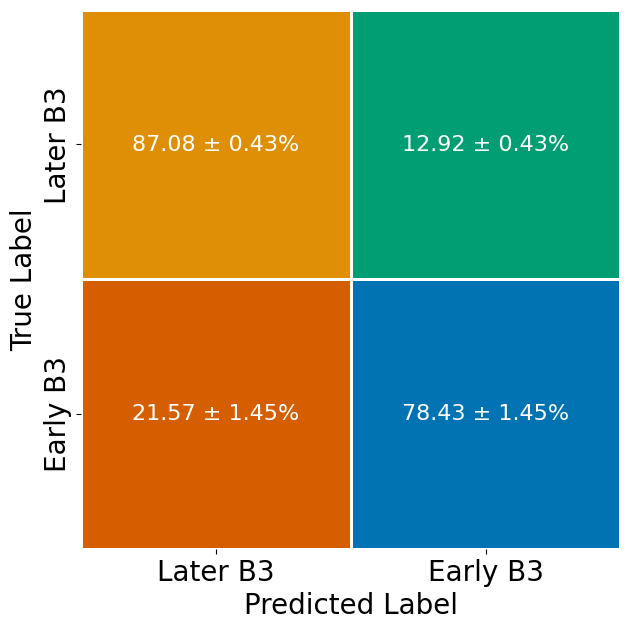

1219


In [32]:
Gmag = 12
features_name_mag = features_name
df_mag = df.loc[df["Gmag"]<=Gmag].reset_index(drop=True)
scaler = DataFrameScaler()
df_mag[features_name_mag] = scaler.scale(df_mag[features_name_mag])
skiff_mag = df_mag.loc[df_mag["label"].notna()].reset_index(drop=True)
X = skiff_mag[features_name]
y = skiff_mag['B3']
base_filename = f"B3_cut_G{Gmag}_V3"
best_params, best_score, sorted_features, results, CM_array, CM_std = perform_grid_search_and_validation(X, y, path, base_filename,skiff_mag,df_mag)
    

In [109]:
nuevos_candidatos =  df.loc[((df["B2_cut_probability"]>=0.6)&(df["B3_cut_probability"]<0.6))|
      ((df["B3_cut_probability"]>=0.6)&(df["B2_cut_probability"]<0.6))]

In [114]:
len(nuevos_candidatos.loc[nuevos_candidatos["B3_cut_probability"]<=0.7]) / len(nuevos_candidatos)

0.8422114608555287

In [35]:
brf = joblib.load("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V3/B3_cut_G12_V3/skiff_rf.sav")

In [93]:
data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V3/B3_cut_G12_V3/Data.csv")

/tmp/ipykernel_9585/173934979.py:1: DtypeWarning: Columns (49,50,51,52,72,75) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V3/B3_cut_G12_V3/Data.csv")


In [101]:
df = data.loc[(data["B3_cut_probability"]>=0.6)&(data["B3_cut_split"].isna())]

In [102]:
df_for_lamost = df[["ra","dec"]]
df_for_lamost["sep"] = 5
df_for_lamost.to_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Candidates_Lamost_B3_not_searched.csv',
                     header=False,sep=",",index=False)

/tmp/ipykernel_9585/588543198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_lamost["sep"] = 5


In [83]:
df_lamost_B3 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_not_searched_sp.csv")
df_lamost_B2 = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/spectra/LAMOST_low_resolution/Lamost_Contain_Rectangle_sp.csv")

In [84]:
df_sp = pd.concat([df_lamost_B2[["index", "sp"]], df_lamost_B3[["index", "sp"]]]).drop_duplicates("index", keep="last")
data = data.merge(df_sp, how="left", on="index")


In [85]:
#data = data.loc[data["sp"].notna()]

In [86]:
#data = data.loc[data["B3_cut_probability"]>=0.6]

In [87]:
df = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv')


/tmp/ipykernel_9585/3976861212.py:1: DtypeWarning: Columns (50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv')


In [88]:
df = df.rename(columns={"B3_cut_probability":"B3_lamost"})

In [90]:
data = data.merge(df[["index","B3_lamost"]],how="left",on=["index"])

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability,B3,B3_cut_split,B3_cut_probability,sp,B3_lamost
6,236399,4288653354806251648,290.833695,1.950657,0.019797,0.018471,0.232874,0.022487,10.356110,-0.021744,...,0.325611,0.217659,1.0,test,0.592500,1.0,test,0.628,NaN,0.563333
464,602720,5597765983680009216,120.013552,-28.840507,0.034957,0.042287,-0.071596,0.053725,-1.332639,-1.924660,...,0.387550,0.267076,1.0,test,0.440000,1.0,test,0.622,NaN,0.575000
685,1037055,5258741400139579008,153.969131,-57.375005,0.016115,0.015937,0.445812,0.019178,23.246195,-7.813324,...,1.041829,0.624434,1.0,test,0.609167,1.0,test,0.604,NaN,0.529167
1000,926599,4658137739001073280,79.443263,-69.849230,0.019337,0.020476,-0.001376,0.021393,-0.064304,2.006358,...,-0.012667,0.007724,1.0,test,0.662500,1.0,test,0.612,NaN,0.585833
1197,1083771,5854670414570411392,215.687560,-60.653596,0.011188,0.017330,0.528824,0.023904,22.123154,-4.169001,...,0.442529,0.294541,1.0,test,0.642500,1.0,test,0.662,NaN,0.591625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99264,1089170,5932560230724053632,243.112486,-54.495525,0.012048,0.008692,0.478393,0.016915,28.282284,-4.703579,...,0.298259,0.202194,NaN,NaN,0.485833,NaN,NaN,0.604,NaN,0.550000
99297,1089650,457643544382479616,36.991636,56.701248,0.009820,0.010487,0.494385,0.015496,31.904465,-0.283405,...,0.500272,0.329279,NaN,NaN,0.556667,NaN,NaN,0.620,NaN,0.568333
99326,1090082,3317826643769943168,93.319555,4.736299,0.015256,0.014651,0.497444,0.018967,26.226667,-0.131864,...,0.481943,0.314095,NaN,NaN,0.555833,NaN,NaN,0.610,NaN,0.567500
99353,1090349,6056778862433551488,193.529691,-60.387012,0.011557,0.013988,0.413467,0.018173,22.751670,-4.724755,...,0.280985,0.191311,NaN,NaN,0.482500,NaN,NaN,0.648,NaN,0.590833


## Revisar el entrenamiento sin normalizar features, debiese dar lo mismo

In [20]:
import pandas as pd
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                    StratifiedKFold, StratifiedShuffleSplit,
                                    cross_val_score)
from imblearn.ensemble import BalancedRandomForestClassifier


In [21]:
features_name = ['j_m',
 'h_m',
 'ks_m',
 'phot_g_mean_mag',
 'phot_bp_mean_mag',
 'phot_rp_mean_mag',
 'j_m-h_m',
 'j_m-ks_m',
 'j_m-phot_g_mean_mag',
 'j_m-phot_bp_mean_mag',
 'j_m-phot_rp_mean_mag',
 'h_m-ks_m',
 'h_m-phot_g_mean_mag',
 'h_m-phot_bp_mean_mag',
 'h_m-phot_rp_mean_mag',
 'ks_m-phot_g_mean_mag',
 'ks_m-phot_bp_mean_mag',
 'ks_m-phot_rp_mean_mag',
 'phot_g_mean_mag-phot_bp_mean_mag',
 'phot_g_mean_mag-phot_rp_mean_mag',
 'phot_bp_mean_mag-phot_rp_mean_mag',
 'parallax_error',
 'parallax_over_error',
 'parallax',
 'pmra',
 'pmdec',
 'pmdec_error',
 'pmra_error',
 'astrometric_sigma5d_max',
 'astrometric_excess_noise',
 'ruwe',
 'astrometric_gof_al',
 'ipd_gof_harmonic_amplitude',
 'astrometric_excess_noise_sig']

In [22]:
df = pd.read_csv("data_before_KS_test.csv")

/tmp/ipykernel_626818/3295208451.py:1: DtypeWarning: Columns (49,50,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_before_KS_test.csv")


In [23]:
df.loc[df['label']<=1.3,'B3'] = 1
df.loc[df['label']>1.3,'B3'] = 0

In [24]:
df_mag = df.loc[df["phot_g_mean_mag"]<=12].reset_index(drop=True)
skiff_mag = df_mag.loc[df_mag["label"].notna()].reset_index(drop=True)

In [25]:
X = skiff_mag[features_name]
y = skiff_mag['B3']

In [26]:
best_params = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/_best_params.csv")

In [27]:
#entrenamiento de un modelo
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_params_dict = best_params.iloc[0].to_dict()
best_brfc = BalancedRandomForestClassifier(**best_params_dict)

In [28]:
best_brfc.fit(X_train, Y_train)
#joblib.dump(best_brfc,f'{full_path}/skiff_rf.sav')
# predecir todo el modelo 


/home/nicolas/miniconda3/envs/RF_backup/lib/python3.11/site-packages/imblearn/ensemble/_forest.py:558: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(


BalancedRandomForestClassifier(max_depth=30, max_features='log2',
                               n_estimators=1200, sampling_strategy='majority')

In [29]:
result = best_brfc.predict_proba(df_mag[best_brfc.feature_names_in_])[:, 1]

In [30]:
df_mag["B3_cut_probability"] = result

In [2]:
import pandas as pd

In [31]:
df_mag.to_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv")

In [6]:
df_antiguo = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_427801/32864098.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df_antiguo = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [4]:
df_mag = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv")

/tmp/ipykernel_427801/4087062804.py:1: DtypeWarning: Columns (50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mag = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data_trained_with_B3.csv")


In [7]:
df_mag = df_mag.merge(df_antiguo[["index","B2_cut_probability"]],on="index",how="inner")

In [8]:
import matplotlib.pyplot as plt

In [16]:
df_mag

,Unnamed: 0,index,source_id,ra,dec,ra_error,dec_error,parallax,parallax_error,parallax_over_error,...,ks_m-phot_g_mean_mag,ks_m-phot_bp_mean_mag,ks_m-phot_rp_mean_mag,phot_g_mean_mag-phot_bp_mean_mag,phot_g_mean_mag-phot_rp_mean_mag,phot_bp_mean_mag-phot_rp_mean_mag,duplicated,B3,B3_cut_probability,B2_cut_probability
0,0,4377,5867262056094720256,210.788953,-60.399609,0.005978,0.009415,0.351307,0.012514,28.072306,...,-1.946995,-2.459917,-1.244953,-0.512922,0.702042,1.214964,NaN,1.0,0.951667,0.928333
1,1,1036997,465798136783420032,40.879047,62.059394,0.016799,0.018728,0.297585,0.026911,11.058279,...,-1.330405,-1.560003,-0.914638,-0.229598,0.415767,0.645365,NaN,1.0,0.857500,0.847500
2,2,572316,5864666727635499904,206.640463,-62.889316,0.018872,0.022404,0.609050,0.033216,18.336296,...,-0.174629,-0.212529,-0.059639,-0.037900,0.114990,0.152890,NaN,1.0,0.777500,0.708333
3,3,400503,5311906841793959936,139.155186,-51.939581,0.010610,0.011651,0.364554,0.011761,30.996029,...,-1.528118,-1.914056,-0.948690,-0.385938,0.579428,0.965366,NaN,1.0,0.970833,0.971667
4,4,225971,5350357313186767104,161.140513,-59.737608,0.021567,0.021763,0.430756,0.024832,17.346905,...,-0.321917,-0.352225,-0.180605,-0.030308,0.141312,0.171620,NaN,1.0,0.972500,0.960000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,99383,1090775,5930430098664887296,248.531434,-54.448183,0.013537,0.009705,0.662841,0.017796,37.247540,...,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995,NaN,NaN,0.235000,0.215000
99384,99384,1090785,203937691597823488,69.770362,41.249985,0.016364,0.009660,1.189286,0.019677,60.441757,...,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237,NaN,NaN,0.615833,0.450000
99385,99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,NaN,NaN,0.777500,0.783333
99386,99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,NaN,NaN,0.920833,0.907500


In [15]:
df_antiguo

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-Gmag,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability
0,4377,5867262056094720256,210.788953,-60.399609,0.005978,0.009415,0.351307,0.012514,28.072306,-4.971972,...,-1.946995,-2.459917,-1.244953,-0.512922,0.702042,1.214964,0.702042,1.0,train,0.928333
1,1036997,465798136783420032,40.879047,62.059394,0.016799,0.018728,0.297585,0.026911,11.058279,-0.291098,...,-1.330405,-1.560003,-0.914638,-0.229598,0.415767,0.645365,0.415767,1.0,train,0.847500
2,572316,5864666727635499904,206.640463,-62.889316,0.018872,0.022404,0.609050,0.033216,18.336296,-4.708172,...,-0.174629,-0.212529,-0.059639,-0.037900,0.114990,0.152890,0.114990,1.0,train,0.708333
3,400503,5311906841793959936,139.155186,-51.939581,0.010610,0.011651,0.364554,0.011761,30.996029,-5.087674,...,-1.528118,-1.914056,-0.948690,-0.385938,0.579428,0.965366,0.579428,1.0,train,0.971667
4,225971,5350357313186767104,161.140513,-59.737608,0.021567,0.021763,0.430756,0.024832,17.346905,-7.618940,...,-0.321917,-0.352225,-0.180605,-0.030308,0.141312,0.171620,0.141312,1.0,test,0.960000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,1090775,5930430098664887296,248.531434,-54.448183,0.013537,0.009705,0.662841,0.017796,37.247540,-2.524056,...,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995,0.221032,NaN,NaN,0.215000
99384,1090785,203937691597823488,69.770362,41.249985,0.016364,0.009660,1.189286,0.019677,60.441757,-1.227252,...,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237,0.208548,NaN,NaN,0.450000
99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,0.352274,NaN,NaN,0.783333
99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,0.187722,NaN,NaN,0.907500


In [19]:
df_mag = df_mag.loc[df_mag["B3"].isna()]

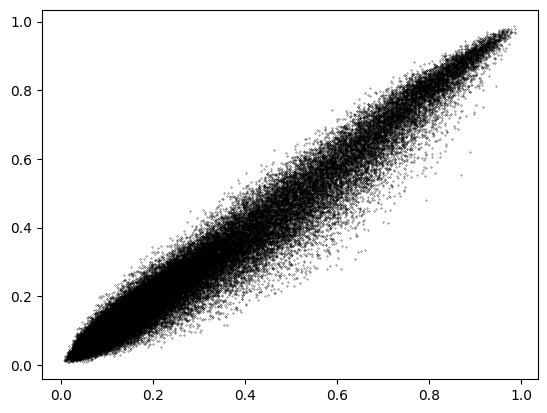

In [21]:
plt.plot(df_mag["B3_cut_probability"],df_mag["B2_cut_probability"],"k.",ms=0.5)

In [27]:
len(
    df_mag[
        ((df_mag["B3_cut_probability"] >= 0.6) & (df_mag["B2_cut_probability"] < 0.6)) |
        ((df_mag["B3_cut_probability"] < 0.6) & (df_mag["B2_cut_probability"] >= 0.6))
    ]
) / len(df_mag)


0.030176931620856343

In [67]:
3%

,index,source_id,ra,dec,ra_error,dec_error,parallax,parallax_error,parallax_over_error,pmra,...,ks_m-phot_g_mean_mag,ks_m-phot_bp_mean_mag,ks_m-phot_rp_mean_mag,phot_g_mean_mag-phot_bp_mean_mag,phot_g_mean_mag-phot_rp_mean_mag,phot_bp_mean_mag-phot_rp_mean_mag,duplicated,B2,predict,B2_cut_probability
0,4377,5867262056094720256,210.788953,-60.399609,0.005978,0.009415,0.351307,0.012514,28.072306,-4.971972,...,-1.946995,-2.459917,-1.244953,-0.512922,0.702042,1.214964,NaN,1.0,0.945000,0.928333
1,1036997,465798136783420032,40.879047,62.059394,0.016799,0.018728,0.297585,0.026911,11.058279,-0.291098,...,-1.330405,-1.560003,-0.914638,-0.229598,0.415767,0.645365,NaN,1.0,0.840833,0.847500
2,572316,5864666727635499904,206.640463,-62.889316,0.018872,0.022404,0.609050,0.033216,18.336296,-4.708172,...,-0.174629,-0.212529,-0.059639,-0.037900,0.114990,0.152890,NaN,1.0,0.750000,0.708333
3,400503,5311906841793959936,139.155186,-51.939581,0.010610,0.011651,0.364554,0.011761,30.996029,-5.087674,...,-1.528118,-1.914056,-0.948690,-0.385938,0.579428,0.965366,NaN,1.0,0.976667,0.971667
4,225971,5350357313186767104,161.140513,-59.737608,0.021567,0.021763,0.430756,0.024832,17.346905,-7.618940,...,-0.321917,-0.352225,-0.180605,-0.030308,0.141312,0.171620,NaN,1.0,0.953333,0.960000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,1090775,5930430098664887296,248.531434,-54.448183,0.013537,0.009705,0.662841,0.017796,37.247540,-2.524056,...,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995,NaN,NaN,0.220000,0.215000
99384,1090785,203937691597823488,69.770362,41.249985,0.016364,0.009660,1.189286,0.019677,60.441757,-1.227252,...,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237,NaN,NaN,0.449167,0.450000
99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,NaN,NaN,0.780278,0.783333
99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,NaN,NaN,0.913276,0.907500


In [ ]:
df_total.loc[X_train.index,'B2_cut_split'] = 'train'
df_total.loc[X_test.index,'B2_cut_split'] = 'test'
df_total.loc[df_total["B2_cut_split"].isna(),"B2_cut_split"] = "no_used"
df_total['B2_cut_probability'] = best_brfc.predict_proba(df_total[best_brfc.feature_names_in_])[:, 1]
df_total[best_brfc.feature_names_in_] = scaler.inverse_scale(df_total[best_brfc.feature_names_in_])
df_total.to_csv(f'{full_path}/Data.csv',index=False)    

# Performance of the BRF

La pregunta es: Si los primeros labels son mas permisivos, entonces el modelo 1 deberia contener al modelo 2.
Estamos considerando solamente estrellas que esten dentro del 99 y 1 % en el espacio de parametros. ffhfff

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [155]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


/tmp/ipykernel_6160/2737805224.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [160]:
df["d"] = 1000/df["Parallax"]

In [161]:
df.sort_values(by="B2_cut_probability",ascending=False).head(100)[["ra",
                                                                   "dec",
                                                                   "skiff_type_list",
                                                                   "label"]].to_csv("high_prob_massive_stars.csv",index=False)

In [12]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
df = df.loc[df["B2_cut_split"].notna()]

astrometric = ['Parallax',
       'Parallax_error', 'Parallax_over_error', 'pmRA', 'pmDEC', 'pmRA_error',
       'pmDEC_error','Sigma5d_max', 'Excess_noise', 'RUWE', 'Gof_al','Ipd_gof_harmonic_amplitude', 'Excess_noise_sig']

mag_features = [ 'Jmag','Hmag', 'Ksmag','Gmag', 'BPmag',"RPmag"]
color = ['Jmag-Hmag', 'Jmag-Ksmag',
       'Jmag-Gmag', 'Jmag-BPmag', 'Jmag-RPmag', 'Hmag-Ksmag', 'Hmag-Gmag',
       'Hmag-BPmag', 'Hmag-RPmag', 'Ksmag-Gmag', 'Ksmag-BPmag', 'Ksmag-RPmag',
       'Gmag-BPmag', 'Gmag-RPmag', 'BPmag-RPmag']

features_name = astrometric+mag_features+color

scaler = DataFrameScaler()
df[features_name] = scaler.scale(df[features_name])
df.loc[df['label']<=1.2,'B2'] = 1
df.loc[df['label']>1.2,'B2'] = 0

X = df[features_name]
y = df['B2']

# Iniciar la validación cruzada
array = np.zeros((len(np.unique(y)), len(np.unique(y)), 20))
results = []
sss = StratifiedShuffleSplit(n_splits=20, test_size=0.2, random_state=42)

best_params = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/_best_params.csv").iloc[0].to_dict()

futures = [parallel_function.remote(train_index, test_index, iteration, X, y, best_params) for iteration, (train_index, test_index) in enumerate(sss.split(X, y))]


iteration = 0
for future in ray.get(futures):
    array_2, result = future
    array[:, :, iteration] = array_2
    results.extend(result)
    iteration += 1
ray.shutdown()

results = pd.DataFrame(results)
CM_array = array.mean(axis=2)
CM_std = array.std(axis=2)

/tmp/ipykernel_20902/3662128544.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [114]:
import pandas as pd

# Calcular la media y desviación estándar por clase
mean_df = results.groupby("Class").mean()
std_df = results.groupby("Class").std()

# Formatear los valores como "media ± std"
formatted_df_B2 = mean_df.astype(str) + " ± " + std_df.astype(str)

# Mostrar solo 2 filas
formatted_df_B2 = formatted_df.head(2)

# Mostrar el DataFrame resultante
print(formatted_df)

                     Iteration                                  Precision  \
Class                                                                       
0.0    9.5 ± 5.916079783099616  0.9681839739454793 ± 0.001730387633422687   
1.0    9.5 ± 5.916079783099616   0.4800378116047412 ± 0.00993513951755643   

                                          Recall  \
Class                                              
0.0    0.8779530093337625 ± 0.004806700365962868   
1.0    0.7960182025028442 ± 0.011608321381037859   

                                         F1 Score  
Class                                              
0.0    0.9208559352647697 ± 0.0027078200836826508  
1.0     0.5988368681473442 ± 0.009001299501037612  


In [132]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
df = df.loc[df["B2_cut_split"].notna()]

astrometric = ['Parallax',
       'Parallax_error', 'Parallax_over_error', 'pmRA', 'pmDEC', 'pmRA_error',
       'pmDEC_error','Sigma5d_max', 'Excess_noise', 'RUWE', 'Gof_al','Ipd_gof_harmonic_amplitude', 'Excess_noise_sig']

mag_features = [ 'Jmag','Hmag', 'Ksmag','Gmag', 'BPmag',"RPmag"]
color = ['Jmag-Hmag', 'Jmag-Ksmag',
       'Jmag-Gmag', 'Jmag-BPmag', 'Jmag-RPmag', 'Hmag-Ksmag', 'Hmag-Gmag',
       'Hmag-BPmag', 'Hmag-RPmag', 'Ksmag-Gmag', 'Ksmag-BPmag', 'Ksmag-RPmag',
       'Gmag-BPmag', 'Gmag-RPmag', 'BPmag-RPmag']

features_name = astrometric+mag_features+color

scaler = DataFrameScaler()
df[features_name] = scaler.scale(df[features_name])
df.loc[df['label']<=1.3,'B3'] = 1
df.loc[df['label']>1.3,'B3'] = 0

X = df[features_name]
y = df['B3']

# Iniciar la validación cruzada
array = np.zeros((len(np.unique(y)), len(np.unique(y)), 20))
results = []
sss = StratifiedShuffleSplit(n_splits=20, test_size=0.2, random_state=42)

best_params = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/_best_params.csv").iloc[0].to_dict()

futures = [parallel_function.remote(train_index, test_index, iteration, X, y, best_params) for iteration, (train_index, test_index) in enumerate(sss.split(X, y))]


iteration = 0
for future in ray.get(futures):
    array_2, result = future
    array[:, :, iteration] = array_2
    results.extend(result)
    iteration += 1
ray.shutdown()

results = pd.DataFrame(results)
CM_array = array.mean(axis=2)
CM_std = array.std(axis=2)

/tmp/ipykernel_20902/3516750423.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
2025-03-17 16:06:25,756	INFO worker.py:1673 -- Started a local Ray instance.
(parallel_function pid=25825) /home/nicolas/miniconda3/envs/RF/lib/python3.11/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
(parallel_function pid=25825)   warn(
(parallel_function pid=25810) /home/nicolas/miniconda3/envs/RF/lib/python3.11/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in th

In [136]:
results.groupby("Class").mean()

,Iteration,Precision,Recall,F1 Score
Class,,,,
0.0,9.5,0.948078,0.875724,0.910456
1.0,9.5,0.563501,0.769747,0.650600


In [138]:
# Calcular la media y desviación estándar por clase
mean_df = results.groupby("Class").mean()
std_df = results.groupby("Class").std()

# Formatear los valores como "media ± std"
formatted_df_B3 = mean_df.astype(str) + " ± " + std_df.astype(str)

# Mostrar solo 2 filas
formatted_df_B3 = formatted_df_B3.head(2)

formatted_df_B3

,Iteration,Precision,Recall,F1 Score
Class,,,,
0.0,9.5 ± 5.916079783099616,0.948077669957588 ± 0.003128727231785161,0.8757240204429302 ± 0.004515199339144044,0.9104558747582407 ± 0.002535847329688105
1.0,9.5 ± 5.916079783099616,0.5635006291310451 ± 0.008686727719565055,0.7697465249386755 ± 0.014887632916989147,0.6505995914113095 ± 0.0086991518357646


In [139]:
formatted_df = pd.concat([formatted_df_B2,formatted_df_B3])

In [140]:
formatted_df

,Iteration,Precision,Recall,F1 Score
Class,,,,
0.0,9.5 ± 5.916079783099616,0.9681839739454793 ± 0.001730387633422687,0.8779530093337625 ± 0.004806700365962868,0.9208559352647697 ± 0.0027078200836826508
1.0,9.5 ± 5.916079783099616,0.4800378116047412 ± 0.00993513951755643,0.7960182025028442 ± 0.011608321381037859,0.5988368681473442 ± 0.009001299501037612
0.0,9.5 ± 5.916079783099616,0.948077669957588 ± 0.003128727231785161,0.8757240204429302 ± 0.004515199339144044,0.9104558747582407 ± 0.002535847329688105
1.0,9.5 ± 5.916079783099616,0.5635006291310451 ± 0.008686727719565055,0.7697465249386755 ± 0.014887632916989147,0.6505995914113095 ± 0.0086991518357646


In [141]:
formatted_df.index = ["Later than B2", "B2 or earlier", "Later than B3", "B3 or earlier"]

In [142]:
formatted_df = formatted_df.drop(columns=["Iteration"])

In [155]:
def format_custom(value):
    """Redondea la media a 3 decimales y el error a 1 decimal."""
    mean, std = value.split(" ± ")
    mean, std = float(mean), float(std)
    
    return f"{mean:.3f} ± {std:.3f}"
    
    # Determinar el número de decimales donde aparece el primer decimal del error
    decimal_places = max(0, abs(int(np.floor(np.log10(std_rounded)))))  # Evitar valores negativos
    
    # Redondear la media con la misma precisión del error
    mean_rounded = round(mean, decimal_places)
    
    return f"{mean_rounded} ± {std_rounded}"


# Aplicar la función a todo el DataFrame
print(formatted_df.applymap(format_custom).to_latex())

\begin{tabular}{llll}
\toprule
 & Precision & Recall & F1 Score \\
\midrule
Later than B2 & 0.968 ± 0.002 & 0.878 ± 0.005 & 0.921 ± 0.003 \\
B2 or earlier & 0.480 ± 0.010 & 0.796 ± 0.012 & 0.599 ± 0.009 \\
Later than B3 & 0.948 ± 0.003 & 0.876 ± 0.005 & 0.910 ± 0.003 \\
B3 or earlier & 0.564 ± 0.009 & 0.770 ± 0.015 & 0.651 ± 0.009 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_20902/3081197550.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(formatted_df.applymap(format_custom).to_latex())


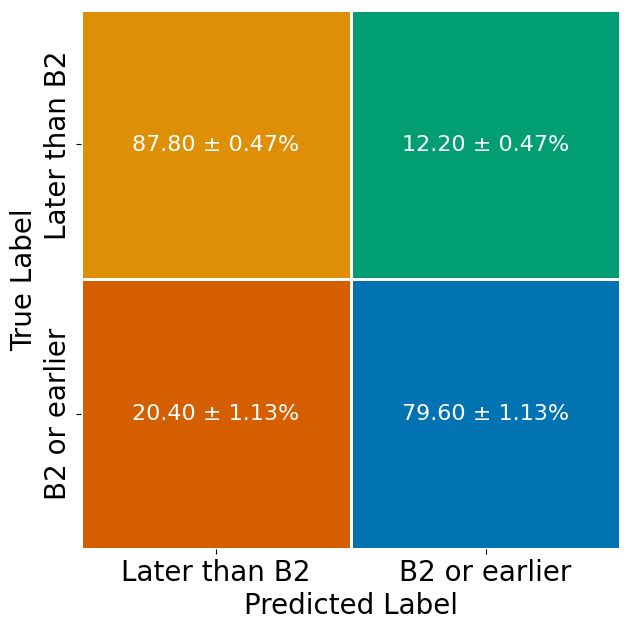

In [53]:
plot_confusion_matrix(CM_array, CM_std,["Later than B2", "B2 or earlier"],'/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Confusion_matrix.pdf')


In [156]:
y_prob = df.loc[df["B2_cut_split"]=="test"]["B2_cut_probability"]
y_test = df.loc[df["B2_cut_split"]=="test"]["B2"]

In [157]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob)
thresholds = np.append(thresholds, 1)

In [158]:
df = pd.DataFrame({"precision":precision,"recall":recall,"thresholds":thresholds})

In [159]:
colorblind_palette = sns.color_palette("colorblind", 4)

In [160]:
colorblind_palette[0]

(0.00392156862745098, 0.45098039215686275, 0.6980392156862745)

/tmp/ipykernel_20902/3830611015.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precision_mean = df.groupby("prob_bin")["precision"].mean()
/tmp/ipykernel_20902/3830611015.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precision_std = df.groupby("prob_bin")["precision"].std()


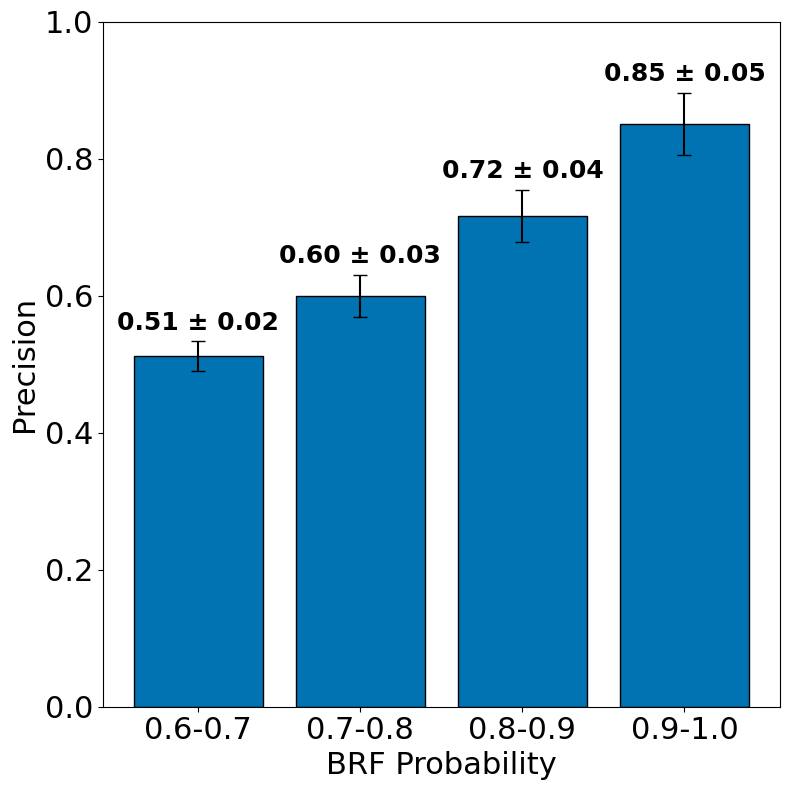

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definir los bins y las etiquetas
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Crear una nueva columna con los bins
df['prob_bin'] = pd.cut(df['thresholds'], bins=bins, labels=labels, right=True)

# Calcular la media y la desviación estándar de la precisión por bin
precision_mean = df.groupby("prob_bin")["precision"].mean()
precision_std = df.groupby("prob_bin")["precision"].std()

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 8))

#
# Dibujar las barras con barras de error
ax.bar(precision_mean.index, precision_mean, yerr=precision_std, capsize=5, 
       color=colorblind_palette[0], edgecolor='black')

# Agregar etiquetas con los valores de precisión en la parte superior de cada barra
for idx, (bin_label, mean_value) in enumerate(precision_mean.items()):
    std_value = precision_std[bin_label]
    ax.text(idx, mean_value + std_value + 0.01, f'{mean_value:.2f} ± {std_value:.2f}', 
            ha='center', va='bottom', fontsize=18, fontweight='bold')

# Configurar etiquetas y título
ax.set_xlabel('BRF Probability', fontsize=22)
ax.set_ylabel('Precision', fontsize=22)
ax.set_ylim(0, 1)  # Ajustar el eje y al rango de precisión [0,1]

# Ajustar el tamaño de las etiquetas del eje x e y
ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)

# Ajustar las etiquetas del eje x
plt.xticks(rotation=0)

# Ajustar el diseño
plt.tight_layout()

# Guardar y mostrar el gráfico#
plt.savefig('/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Precision_dif_tresholds.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [166]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_20902/3662128544.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [171]:
path_plots = '/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/plots/'

In [167]:
df_no_train = df.loc[df["B2_cut_split"].isna()].reset_index(drop=True)

In [168]:
coord = SkyCoord(ra=df_no_train["ra"].values, dec=df_no_train["dec"].values, unit=(u.deg, u.deg)).galactic
candidates_l_rad = coord.l.radian
candidates_l_rad[candidates_l_rad > np.pi] -= 2. * np.pi
candidates_b_rad = coord.b.radian

df_no_train["l"] = candidates_l_rad*u.radian.to(u.deg)
df_no_train["b"] = candidates_b_rad*u.radian.to(u.deg)

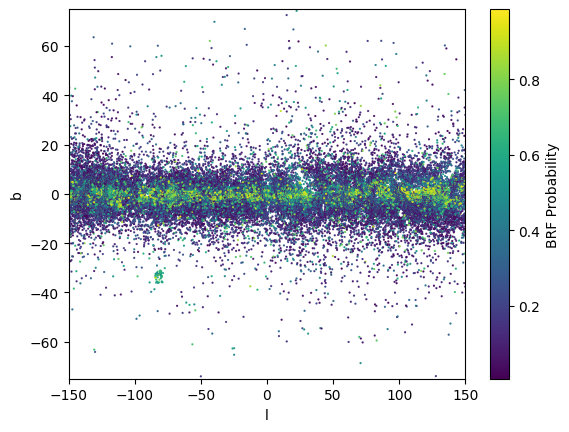

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Create figure and axes
fig, ax = plt.subplots()

# Create scatter plot on specific axes
scatter = sns.scatterplot(data=df_no_train,
                          x="l", y="b",
                          s=2,
                          hue="B2_cut_probability",
                          palette="viridis",
                          edgecolor=None,
                          legend=False, ax=ax)

# Create a colormap and normalize the values for 'B2_cut_probability'
norm = plt.Normalize(df_no_train['B2_cut_probability'].min(), df_no_train['B2_cut_probability'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Add colorbar to the figure, stealing space from the scatter plot
fig.colorbar(sm, ax=ax, label="BRF Probability")
plt.xlim(-150,150)
plt.ylim(-75,75)

plt.savefig(f'{path_plots}/galacatic_plane.pdf', bbox_inches='tight',dpi=300)

plt.show()



In [14]:
test_set = df.loc[df["B2_cut_split"]=="test"]

In [15]:
test_set.loc[(test_set["B2_cut_probability"]>0.5)&(test_set["B2"]==0),"metric"] = "FP"
test_set.loc[(test_set["B2_cut_probability"]<=0.5)&(test_set["B2"]==0),"metric"] = "TN"

test_set.loc[(test_set["B2_cut_probability"]>0.5)&(test_set["B2"]==1),"metric"] = "TP"
test_set.loc[(test_set["B2_cut_probability"]<=0.5)&(test_set["B2"]==1),"metric"] = "FN"

/tmp/ipykernel_1104077/3408785936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set.loc[(test_set["B2_cut_probability"]>0.5)&(test_set["B2"]==0),"metric"] = "FP"


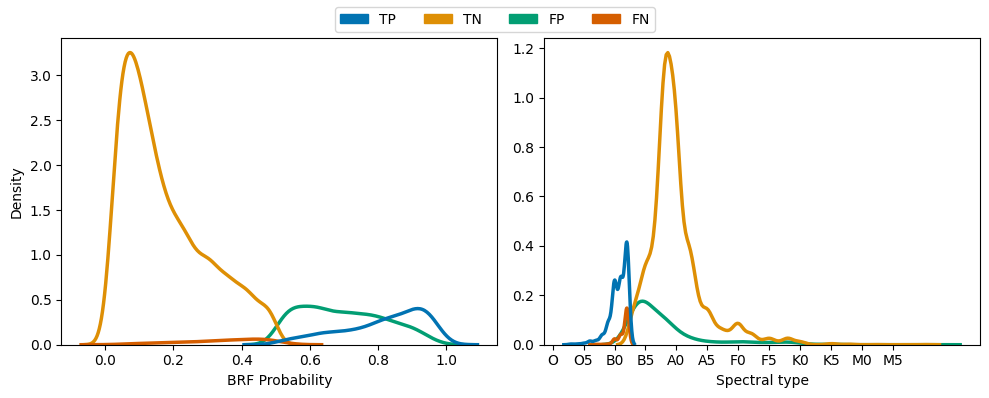

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Crear la figura y los subplots con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Colores personalizados para los tonos
colorblind_palette = sns.color_palette("colorblind", 4)

# Asignar colores a tus categorías
palette = {'TP': colorblind_palette[0],  # primer color
           'TN': colorblind_palette[1],  # segundo color
           'FP': colorblind_palette[2],  # tercer color
           'FN': colorblind_palette[3]}  # cuarto color

# Gráfico 1 - KDE con tonos diferentes para TN, TP, FP, FN
sns.kdeplot(data=test_set, x="B2_cut_probability", hue="metric", ax=axes[0], fill=False, palette=palette, linewidth=2.5)

# Gráfico 2 - KDE con tonos diferentes para TN, TP, FP, FN
sns.kdeplot(data=test_set, x="label", hue="metric", ax=axes[1], fill=False, palette=palette, linewidth=2.5)

# Ajustar los ticks del eje x en el gráfico 2
tick_locations = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5]
tick_labels = ['O', 'O5', 'B0', 'B5', 'A0', 'A5', 'F0', 'F5', 'K0', 'K5', 'M0', 'M5']
axes[1].set_xticks(tick_locations)
axes[1].set_xticklabels(tick_labels)

# Etiquetas personalizadas del eje x
axes[0].set_xlabel("BRF Probability")
axes[1].set_xlabel("Spectral type")

# Ocultar las leyendas de los subplots individuales
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[1].set_ylabel("")

# Crear handles y labels manualmente a partir de la paleta
handles = [mpatches.Patch(color=palette[key], label=key) for key in palette.keys()]

# Crear una leyenda compartida
fig.legend(handles=handles, loc='upper center', ncol=4)

# Ajustar el layout para dejar espacio para la leyenda
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardar y mostrar el gráfico
plt.savefig(f'{path_plots}/metrics.pdf', bbox_inches='tight')
plt.show()




In [20]:
test_set.loc[test_set["B2_cut_probability"]>0.5,"predict"] = 1
test_set.loc[test_set["B2_cut_probability"]<=0.5,"predict"] = 0

/tmp/ipykernel_1104077/3841175550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set.loc[test_set["B2_cut_probability"]>0.5,"predict"] = 1


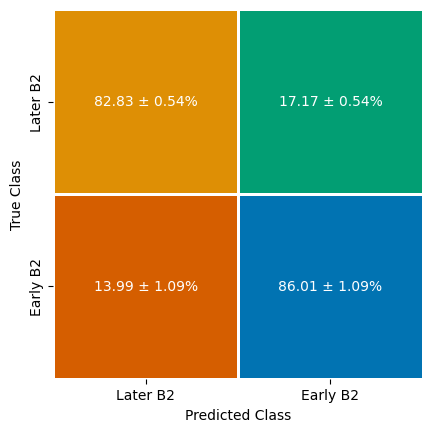

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Definir colores personalizados
colores = [colorblind_palette[1], colorblind_palette[2], colorblind_palette[3],colorblind_palette[0]]

# Crear el colormap discreto
cmap_discreto = ListedColormap(colores)

# Crear una matriz de 2x2 (4 rectángulos), cada número corresponde a un color
indices_colores = np.array([[0, 1],  # Azul, firebrick
                            [2, 3]]) # Rojo, deepskyblue

# Matriz de texto a mostrar en cada celda
cm = np.array([['82.83 ± 0.54%', '17.17 ± 0.54%'], 
               ['13.99 ± 1.09%', '86.01 ± 1.09%']])

# Agregar etiquetas para los valores 0 y 1
xticklabels = ['Later B2', 'Early B2']
yticklabels = ['Later B2', 'Early B2']

# Graficar el heatmap sin anotar los textos inicialmente
ax = sns.heatmap(indices_colores, cmap=cmap_discreto, cbar=False, square=True, 
                 linewidths=1, annot=cm, fmt='', 
                 xticklabels=xticklabels, yticklabels=yticklabels)

# Cambiar el color de cada anotación dependiendo de la celda
for i, text in enumerate(ax.texts):
    # Cambiar el color del texto según el índice de la celda
    text.set_color('white')

# Agregar etiquetas para los ejes generales
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.savefig(f'{path_plots}/CM_colored.pdf', bbox_inches='tight')
plt.show()



In [45]:
import ast
import pandas as pd
coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")
coded_alonso['source_id'] = coded_alonso['source_id'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
coded_alonso["source_id_list"] = coded_alonso["source_id"]
coded_alonso = coded_alonso.explode("source_id",ignore_index=True)
coded_alonso["source_id"] = coded_alonso["source_id"].astype(int)

/tmp/ipykernel_9705/1236630414.py:3: DtypeWarning: Columns (1,2,9) have mixed types. Specify dtype option on import or set low_memory=False.
  coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


In [81]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_9705/3662128544.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [82]:
df = df.merge(coded_alonso[["source_id","skiff_type","lum_codification_mean"]],how="left",on="source_id")

In [83]:
df = df.drop_duplicates(subset="source_id")

In [101]:
df.loc[(df["label"]==2)&(df["lum_codification_mean"].notna())&(df["B2_cut_split"]=="test")]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability,skiff_type_y,lum_codification_mean
44073,1072204,409354814749891456,25.298004,55.040985,0.016852,0.018054,0.942759,0.027973,33.702260,-0.744698,...,-0.342890,-0.110348,0.224237,0.334585,0.224237,0.0,test,0.130000,A0V,5.0
44081,1072191,4100350714233348864,280.137549,-15.491665,0.014769,0.013966,1.185305,0.017008,69.692960,-2.431316,...,-0.509230,-0.162525,0.310139,0.472664,0.310139,0.0,test,0.193333,"['A0IV', 'B9IV']",4.0
44097,1073482,567276364174989824,0.673800,82.973192,0.031815,0.032361,2.700711,0.037823,71.403060,-12.560170,...,-0.193758,-0.049817,0.129152,0.178969,0.129152,0.0,test,0.143333,"['A0V', 'A0']",5.0
44109,1089287,189036530204635392,78.597055,40.781148,0.026912,0.017879,0.740730,0.034946,21.196556,1.088294,...,-0.419209,-0.112887,0.225591,0.338478,0.225591,0.0,test,0.055833,"['B8', 'A2', 'A0V']",5.0
44113,1073762,4097988207344159872,276.452855,-15.271282,0.017660,0.017058,0.891175,0.020965,42.507774,3.164707,...,-0.535134,-0.121518,0.236073,0.357591,0.236073,0.0,test,0.085833,A0V,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49959,1045614,5330085101881474560,134.539829,-47.613505,0.085957,0.091753,0.298382,0.104985,2.842141,-7.299053,...,-0.911154,-0.317900,0.508564,0.826464,0.508564,0.0,test,0.540833,A0V,5.0
49984,1050284,5234873644092414464,173.254480,-69.271596,0.019839,0.020171,1.264417,0.023167,54.579304,-8.078590,...,-0.358360,0.009126,0.316296,0.307170,0.316296,0.0,test,0.107500,"['A0', 'B9V']",5.0
49988,354135,4055196937074059008,264.839016,-31.091735,0.037556,0.032483,1.097261,0.056016,19.588219,2.264411,...,-0.325318,-0.081884,0.177449,0.259333,0.177449,0.0,test,0.066667,"['A0IV', 'A0', 'A0']",4.0
50029,1044603,5880006628490614528,225.185020,-57.581091,0.010377,0.012026,1.067570,0.015907,67.114240,-8.808871,...,-0.725675,-0.201574,0.362274,0.563848,0.362274,0.0,test,0.091667,A0IV,4.0


In [103]:

df.loc[(df["label"]==2)&(df["lum_codification_mean"]())&(df["B2_cut_split"]=="test")]


,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability,skiff_type_y,lum_codification_mean
44073,1072204,409354814749891456,25.298004,55.040985,0.016852,0.018054,0.942759,0.027973,33.702260,-0.744698,...,-0.342890,-0.110348,0.224237,0.334585,0.224237,0.0,test,0.130000,A0V,5.0
44081,1072191,4100350714233348864,280.137549,-15.491665,0.014769,0.013966,1.185305,0.017008,69.692960,-2.431316,...,-0.509230,-0.162525,0.310139,0.472664,0.310139,0.0,test,0.193333,"['A0IV', 'B9IV']",4.0
44097,1073482,567276364174989824,0.673800,82.973192,0.031815,0.032361,2.700711,0.037823,71.403060,-12.560170,...,-0.193758,-0.049817,0.129152,0.178969,0.129152,0.0,test,0.143333,"['A0V', 'A0']",5.0
44109,1089287,189036530204635392,78.597055,40.781148,0.026912,0.017879,0.740730,0.034946,21.196556,1.088294,...,-0.419209,-0.112887,0.225591,0.338478,0.225591,0.0,test,0.055833,"['B8', 'A2', 'A0V']",5.0
44113,1073762,4097988207344159872,276.452855,-15.271282,0.017660,0.017058,0.891175,0.020965,42.507774,3.164707,...,-0.535134,-0.121518,0.236073,0.357591,0.236073,0.0,test,0.085833,A0V,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49959,1045614,5330085101881474560,134.539829,-47.613505,0.085957,0.091753,0.298382,0.104985,2.842141,-7.299053,...,-0.911154,-0.317900,0.508564,0.826464,0.508564,0.0,test,0.540833,A0V,5.0
49984,1050284,5234873644092414464,173.254480,-69.271596,0.019839,0.020171,1.264417,0.023167,54.579304,-8.078590,...,-0.358360,0.009126,0.316296,0.307170,0.316296,0.0,test,0.107500,"['A0', 'B9V']",5.0
49988,354135,4055196937074059008,264.839016,-31.091735,0.037556,0.032483,1.097261,0.056016,19.588219,2.264411,...,-0.325318,-0.081884,0.177449,0.259333,0.177449,0.0,test,0.066667,"['A0IV', 'A0', 'A0']",4.0
50029,1044603,5880006628490614528,225.185020,-57.581091,0.010377,0.012026,1.067570,0.015907,67.114240,-8.808871,...,-0.725675,-0.201574,0.362274,0.563848,0.362274,0.0,test,0.091667,A0IV,4.0


In [97]:
288/559

0.5152057245080501

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)
from imblearn.metrics import (
    specificity_score,
    geometric_mean_score,
    make_index_balanced_accuracy
)

# Supongamos que tienes tus etiquetas verdaderas y predicciones
# y_true = np.array([...])
# y_pred = np.array([...])

# Para este ejemplo, usaré datos simulados
# Reemplaza esto con tus datos reales
y_true_B3 = test["B3"].values
y_true_B2 = test["B2"].values
y_pred = (test["B2_cut_probability"]>0.5).astype(int)

# Definir las clases
classes = [0, 1]
metrics_dict = {'Class': [], 'Recall': [], 'Precision': [], 'F1 Score': [], 'TNR': []}

# Función para calcular IBA con alpha = 0.1
alpha = 0.1
iba_gmean = make_index_balanced_accuracy(alpha=alpha)(geometric_mean_score)

import numpy as np
import pandas as pd
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
)
metrics_list = []
for cls in classes:
    # Calcular métricas para cada clase y cada conjunto B
    for B_label, y_true in zip(['B2', 'B3'], [y_true_B2, y_true_B3]):
        # Calcular métricas para cada clase
        recall = recall_score(y_true, y_pred, pos_label=cls)
        precision = precision_score(y_true, y_pred, pos_label=cls)
        f1 = f1_score(y_true, y_pred, pos_label=cls)
        tnr = specificity_score(y_true, y_pred, pos_label=cls)
        gmean = geometric_mean_score(y_true, y_pred, pos_label=cls)

        
        # Agregar resultados al diccionario
        metrics_list.append({
            'Class': f'Class {cls}',
            'Dataset': B_label,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'TNR': tnr,
            'G-mean': gmean
        })

# Crear un DataFrame para visualizar las métricas
df_metrics = pd.DataFrame(metrics_list)

print(df_metrics)


In [62]:
df.loc[(df["B2_cut_probability"]>0.5)&(df["B2"]==0),"metric"] = "FP"
df.loc[(df["B2_cut_probability"]<=0.5)&(df["B2"]==0),"metric"] = "TN"

df.loc[(df["B2_cut_probability"]>0.5)&(df["B2"]==1),"metric"] = "TP"
df.loc[(df["B2_cut_probability"]<=0.5)&(df["B2"]==1),"metric"] = "FN"

/tmp/ipykernel_9705/1025987237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[(df["B2_cut_probability"]>0.5)&(df["B2"]==0),"metric"] = "FP"


## Stars outside our source of labels and luminosity class

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
alonso_coded = pd.read_csv("/home/nicolas/nico/git/OB-stars/OBADR3_2arcsecSkiff_coded_alonso.csv")
alonso_coded.rename(columns={"Unnamed: 0":"index"},inplace=True)

/tmp/ipykernel_29440/2635586684.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [20]:
df = df.merge(alonso_coded[['index','type_code',
       'is_binary', 'lum_class_code', 'wd_type_code', 'wr_code', 'pn_code',
       'emission_pec_code', 'profile_pec_code', 'element_pec_code',
       'uncertain_pec_code']],how="left",on="index")

In [21]:
df = df.loc[(df["uncertain_pec_code"]==0)&
           (df["B2_cut_split"]=="test")&
           (df["lum_class_code"].notna())]

In [22]:
df["lum_class"] = np.round(df["lum_class_code"],0)

In [23]:
lum_class_dict = {0: "I", 1: "II", 2: "III", 3: "IV", 4: "V"}
df["lum_class"] = df["lum_class_code"].round(0).astype(int).map(lum_class_dict)


In [24]:
#(df.groupby("lum_class").count() / len(df))*100

In [26]:
df.loc[df["B2_cut_probability"]>0.6,"color"]= 1
df.loc[df["B2_cut_probability"]<=0.6,"color"]= 0

In [48]:
df.keys()

Index(['index', 'source_id', 'ra', 'dec', 'ra_error', 'dec_error', 'Parallax',
       'Parallax_error', 'Parallax_over_error', 'pmRA', 'pmDEC', 'pmRA_error',
       'pmDEC_error', 'Gmag', 'BPmag', 'phot_g_n_obs',
       'phot_g_mean_flux_over_error', 'phot_rp_n_obs',
       'phot_rp_mean_flux_over_error', 'phot_bp_n_obs',
       'phot_bp_mean_flux_over_error', 'RPmag', 'ph_qual', 'tmass_oid', 'Jmag',
       'Hmag', 'Ksmag', 'j_ks_0', 'J-H', 'Sigma5d_max', 'Excess_noise',
       'visibility_periods_used', 'RUWE', 'Gof_al',
       'Ipd_gof_harmonic_amplitude', 'ipd_frac_odd_win', 'ipd_frac_multi_peak',
       'matched_transits_removed', 'astrometric_params_solved',
       'Excess_noise_sig', 'phot_variable_flag', 'skiff_type', 'Bibcode',
       'ra_skiff', 'dec_skiff', 'GroupID_skiff', 'GroupSize_skiff',
       'Sep_skiff', 'mk', 'Bibcode_list', 'index_list', 'skiff_type_list',
       'source_id_list', 'std_sp', 'label', 'Jmag-Hmag', 'Jmag-Ksmag',
       'Jmag-Gmag', 'Jmag-BPmag', 'Jmag-

([<matplotlib.axis.XTick at 0x70dcea3aef10>,
 [Text(0, 0, 'O2'),
  Text(1, 0, 'B0'),
  Text(2, 0, 'A0'),
  Text(3, 0, 'F0'),
  Text(4, 0, 'G0'),
  Text(5, 0, 'K0')])

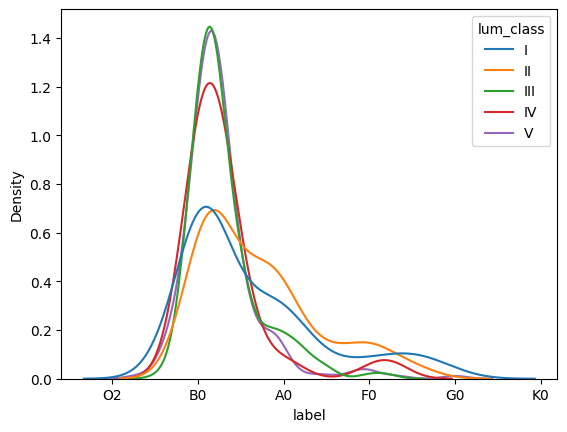

In [53]:
sns.kdeplot(data=df.loc[df["B2_cut_probability"]>0.6],x="label",hue="lum_class",common_norm=False)
x_labels = ["O2","B0", "A0", "F0", "G0", "K0"]
plt.xticks(ticks=range(0, 6), labels=x_labels)



([<matplotlib.axis.XTick at 0x70dcea05d590>,
 [Text(0, 0, 'O2'),
  Text(1, 0, 'B0'),
  Text(2, 0, 'A0'),
  Text(3, 0, 'F0'),
  Text(4, 0, 'G0'),
  Text(5, 0, 'K0')])

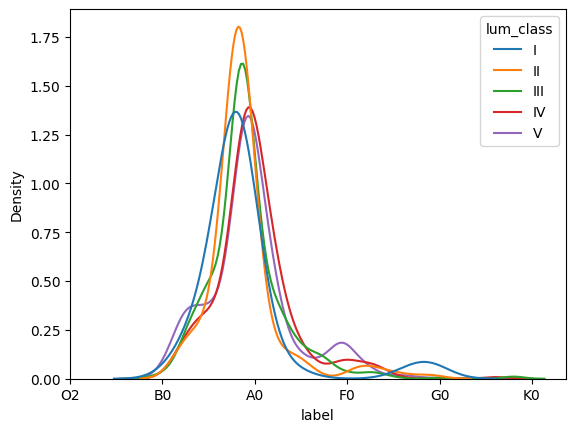

In [62]:
sns.kdeplot(data=df.loc[(df["B2_cut_probability"]<=0.6)&
                        (df["label"])],x="label",hue="lum_class",common_norm=False)
x_labels = ["O2","B0", "A0", "F0", "G0", "K0"]
plt.xticks(ticks=range(0, 6), labels=x_labels)

In [176]:
df_binarias = df.loc[(~df['skiff_type'].str.contains(r'\bOB\b', na=False))&
                        (df["is_binary"]==1)                    
                    ]

In [177]:
df_em = df.loc[df['skiff_type'].str.contains(r'\bem\b', na=False)]

In [178]:
df_OB = df[((df['skiff_type'].str.contains(r'\bOB\b', na=False))|
                (df['skiff_type'].str.contains(r'\bOBe\b', na=False)))]

In [179]:
df_OBe = df_OB.loc[df["emission_pec_code"]==1]
df_OB = df_OB.loc[df["emission_pec_code"]==0]

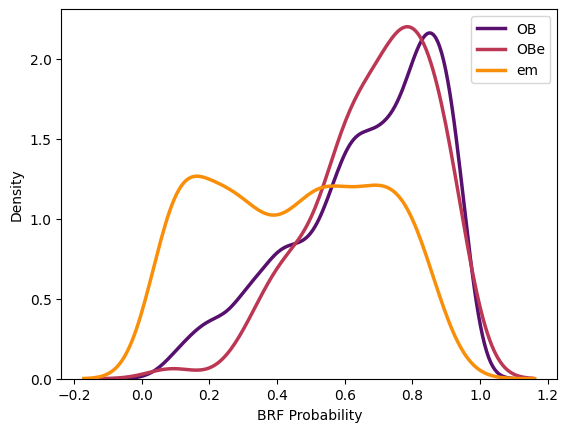

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir tres colores de la paleta 'inferno'
inferno_colors = [plt.cm.inferno(0.25), plt.cm.inferno(0.5), plt.cm.inferno(0.75),plt.cm.inferno(1)]

# Crear gráficos de densidad con colores personalizados
sns.kdeplot(df_OB, x="B2_cut_probability", label="OB", color=inferno_colors[0], linewidth=2.5)
sns.kdeplot(df_OBe, x="B2_cut_probability", label="OBe", color=inferno_colors[1], linewidth=2.5)
sns.kdeplot(df_em, x="B2_cut_probability", label="em", color=inferno_colors[2], linewidth=2.5)
#sns.kdeplot(df_binarias, x="B2_cut_probability", label="Binaries", color=inferno_colors[3], linewidth=2.5)


# Agregar la leyenda
plt.legend()
plt.xlabel("BRF Probability")
plt.savefig(f'{path_plots}/no_includes.pdf', bbox_inches='tight',dpi=300)
plt.show()



In [7]:
import pandas as pd

In [152]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/_features_importance.csv")

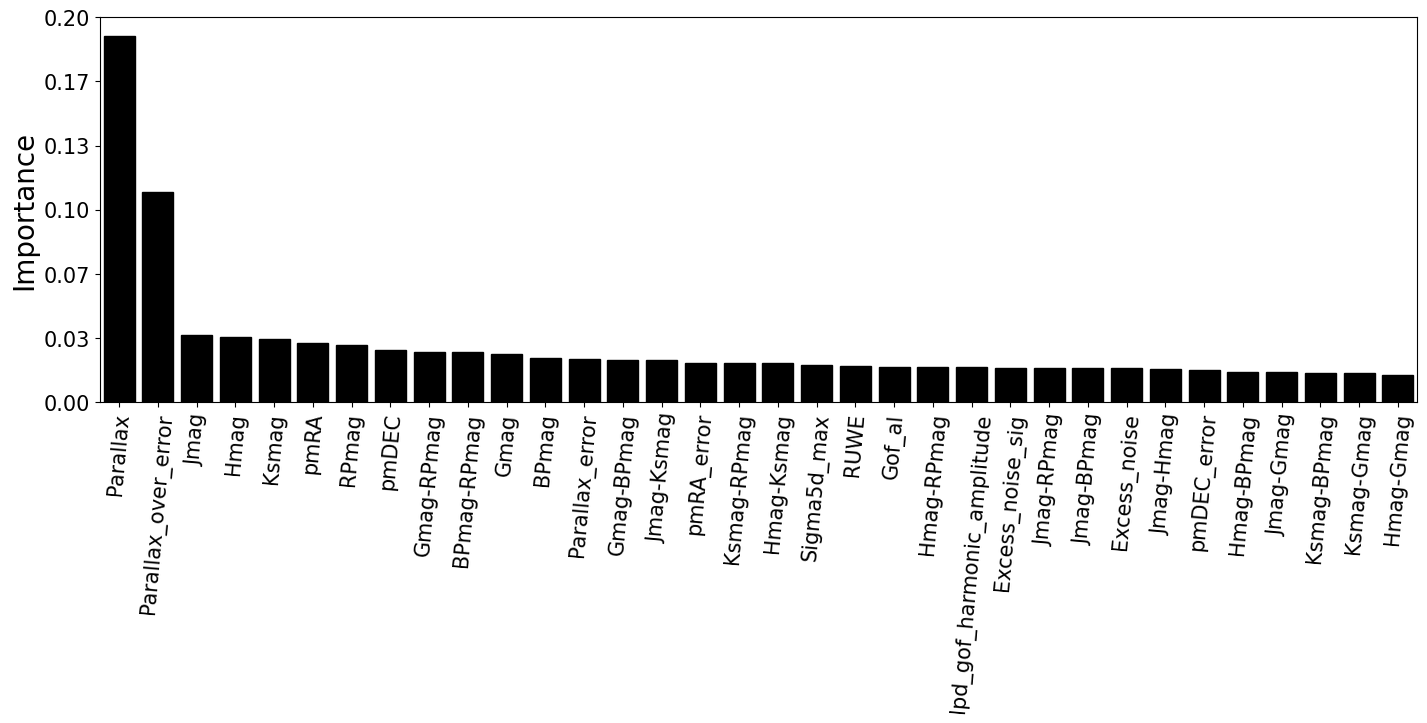

In [154]:

# Configuración del gráfico
plt.figure(figsize=(17, 5))  # Tamaño de la figura
sns.barplot(x="Feature", y="Importance", data=df, color="black", edgecolor="black")

# Configuración de los ejes y etiquetas
plt.xticks(rotation=85)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.ylabel("Importance", size=20)
plt.xlabel("", size=15)

# Ajustar el eje Y con 7 valores y 1 decimal
y_min, y_max = plt.ylim()
y_ticks = np.linspace(y_min, y_max, 7)  # Generar 7 valores equidistantes
plt.yticks(y_ticks, [f"{tick:.2f}" for tick in y_ticks])  # Formatear a 1 decimal

# Guardar el gráfico en PDF
plt.savefig(f"{path_plots}Feature_with_Importance_horizontal.pdf", format='pdf', bbox_inches='tight')

# Mostrar el gráfico
plt.show()

In [146]:
latex_name = ['$\overline{\omega}$', '$\sigma_{\overline{\pi}}$',
       '$\overline{\omega}/\sigma_{\overline{\omega}}$', '$\mu_{\alpha}$',
       '$\mu_{\delta}$', '$\sigma_{\mu_{\alpha}}$', '$\sigma_{\mu_{\delta}}$',
       '$G$', '$G_{BP}$', 'phot_g_n_obs', 'phot_g_mean_flux_over_error',
       'phot_rp_n_obs', 'phot_rp_mean_flux_over_error', 'phot_bp_n_obs',
       'phot_bp_mean_flux_over_error', '$G_{RP}$', 'ph_qual', 'tmass_oid',
       '$J$', '$H$', '$K_{s}$', 'j_ks_0', 'J-H', '$ASM$', '$AEN$',
       'visibility_periods_used', '$RUWE$', '$AGOFAL$', '$IPDGOFHA$',
       'ipd_frac_odd_win', 'ipd_frac_multi_peak', 'matched_transits_removed',
       'astrometric_params_solved', '$\sigma_{AEN}$', 'phot_variable_flag',
       'skiff_type', 'Bibcode', 'ra_skiff', 'dec_skiff', 'GroupID_skiff',
       'GroupSize_skiff', 'Sep_skiff', 'mk', 'Bibcode_list', 'index_list',
       'skiff_type_list', 'source_id_list', 'std_sp', 'label', '$J$-$H$',
       '$J$-$K_{s}$', '$J$-$G$', '$J$-$G_{BP}$', '$J$-$G_{RP}$', '$H$-$K_{s}$',
       '$H$-$G$', '$H$-$G_{BP}$', '$H$-$G_{RP}$', '$K_{s}$-$G$',
       '$K_{s}$-$G_{BP}$', '$K_{s}$-$G_{RP}$', '$G$-$G_{BP}$', '$G$-$G_{RP}$',
       '$G_{BP}$-$G_{RP}$']

In [147]:
'$\overline{\omega}$', '$\sigma_{\overline{\omega}}$',
'$J$', '$H$', '$K_{s}$',
'$\mu_{\alpha}$','$\mu_{\delta}$',

('$\\mu_{\x07lpha}$', '$\\mu_{\\delta}$')

In [148]:
df["Feature"].values

array(['Parallax', 'Parallax_over_error', 'Jmag', 'Hmag', 'Ksmag', 'pmRA',
       'RPmag', 'pmDEC', 'Gmag-RPmag', 'BPmag-RPmag', 'Gmag', 'BPmag',
       'Parallax_error', 'Gmag-BPmag', 'Jmag-Ksmag', 'pmRA_error',
       'Ksmag-RPmag', 'Hmag-Ksmag', 'Sigma5d_max', 'RUWE', 'Gof_al',
       'Hmag-RPmag', 'Ipd_gof_harmonic_amplitude', 'Excess_noise_sig',
       'Jmag-RPmag', 'Jmag-BPmag', 'Excess_noise', 'Jmag-Hmag',
       'pmDEC_error', 'Hmag-BPmag', 'Jmag-Gmag', 'Ksmag-BPmag',
       'Ksmag-Gmag', 'Hmag-Gmag'], dtype=object)

In [149]:
mag_features = ['j_m', 'h_m', 'ks_m','phot_g_mean_mag',
                           'phot_bp_mean_mag', 'phot_rp_mean_mag']
astrometric = [
    "parallax_error",
    "parallax_over_error",
    "parallax",
    "pmra",
    "pmdec",
    "pmdec_error",
    "pmra_error",
    "astrometric_sigma5d_max",
    "astrometric_excess_noise",
    "ruwe",
    "astrometric_gof_al",
    "ipd_gof_harmonic_amplitude",
    "astrometric_excess_noise_sig"]


# Cambiamos el nombre de las variables por estetica


New_names_mag_features = [
    r"$J$",
    r"$H$",
    r"$K_{s}$",
    r"$G$",
    r"$G_{BP}$",
    r"$G_{RP}$"
]


New_names_astrometric = [
    r"$\sigma_{\overline{\pi}}$",
    r"$\overline{\omega}/\sigma_{\overline{\omega}}$",
    r"$\overline{\omega}$",
    r"$\mu_{\alpha}$",
    r"$\mu_{\delta}$",
    r"$\sigma_{\mu_{\delta}}$",
    r"$\sigma_{\mu_{\alpha}}$",
    r"$ASM$",
    r"$AEN$",
    r"$RUWE$",
    r"$AGOFAL$",
    r"$IPDGOFHA$",
    r"$\sigma_{AEN}$"
]



rename_dict = dict(zip(mag_features+astrometric, New_names_mag_features+New_names_astrometric))

# Renombrar las columnas en el DataFrame
df = df.rename(columns=rename_dict)

In [150]:
df["feature_latex"] = ['$\\overline{\\omega}$', '$\\overline{\\omega}/\\sigma_{\\overline{\\omega}}$', '$J$', '$H$', '$K_{s}$', 
 '$\\mu_{\\alpha}$', '$G_{RP}$', '$\\mu_{\\delta}$', '$G$-$G_{RP}$', '$G_{BP}$-$G_{RP}$', '$G$', '$G_{BP}$', 
 '$\\sigma_{\\overline{\\omega}}$', '$G$-$G_{BP}$', '$J$-$K_{s}$', '$\\sigma_{\\mu_{\\alpha}}$', '$K_{s}$-$G_{RP}$', 
 '$H$-$K_{s}$', '$ASM$', '$RUWE$', '$AGOFAL$', '$H$-$G_{RP}$', '$IPDGOFHA$', '$\\sigma_{AEN}$', '$J$-$G_{RP}$', 
 '$J$-$G_{BP}$', '$AEN$', '$J$-$H$', '$\\sigma_{\\mu_{\\delta}}$', '$H$-$G_{BP}$', '$J$-$G$', '$K_{s}$-$G_{BP}$', 
 '$K_{s}$-$G$', '$H$-$G$']


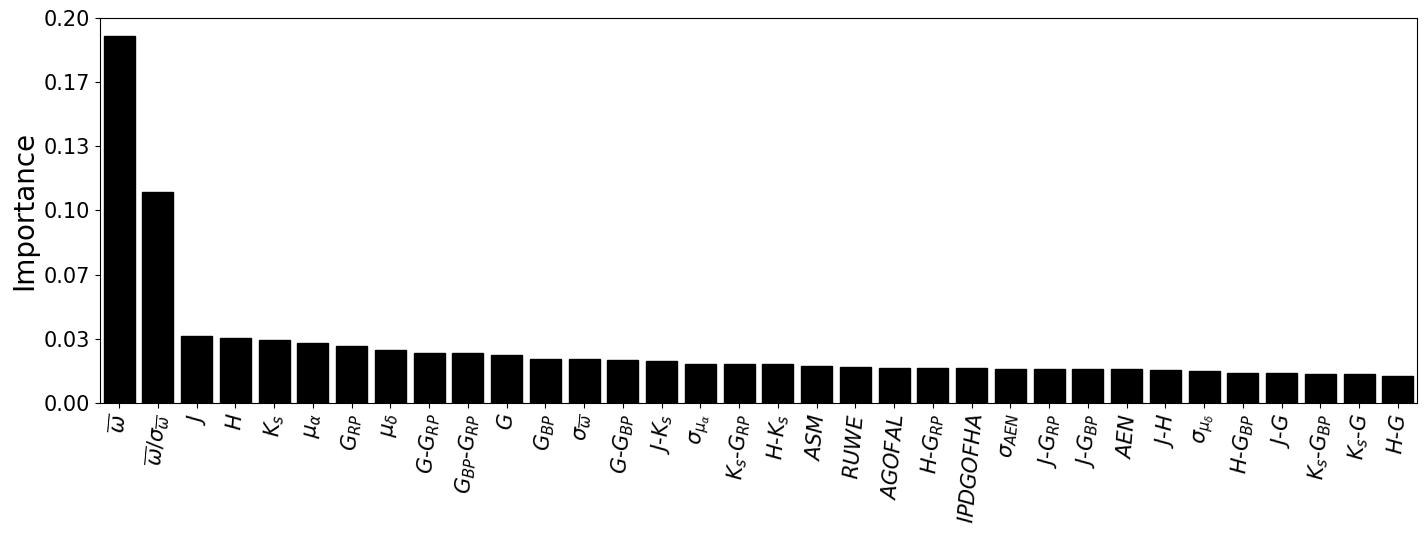

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración del gráfico
plt.figure(figsize=(17, 5))  # Tamaño de la figura
sns.barplot(x="feature_latex", y="Importance", data=df, color="black", edgecolor="black")

# Configuración de los ejes y etiquetas
plt.xticks(rotation=85)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.ylabel("Importance", size=20)
plt.xlabel("", size=15)

# Ajustar el eje Y con 7 valores y 1 decimal
y_min, y_max = plt.ylim()
y_ticks = np.linspace(y_min, y_max, 7)  # Generar 7 valores equidistantes
plt.yticks(y_ticks, [f"{tick:.2f}" for tick in y_ticks])  # Formatear a 1 decimal

# Guardar el gráfico en PDF
plt.savefig(f"{path_plots}Feature_with_Importance_horizontal.pdf", format='pdf', bbox_inches='tight')

# Mostrar el gráfico
plt.show()


In [115]:
import pandas as pd
import numpy as np

In [116]:
simbad_skiff = pd.read_csv("/home/nicolas/nico/git/OB-stars/Comments/OBAGDR3_2arcsecSimbad_2arcsecSkiff_grouped_sd_3_without_OB_with_non_consec_lum.csv")

In [117]:
simbad_skiff = simbad_skiff.loc[(simbad_skiff["simbad_type_codification"].notna())&
                (simbad_skiff["skiff_type_codification_mean"].notna())].reset_index(drop=True)

In [118]:
simbad_skiff = simbad_skiff.loc[simbad_skiff["skiff_lum_class_range_uncertain"]==False] 
simbad_skiff = simbad_skiff.loc[simbad_skiff["simbad_lum_class_range_uncertain"]==False]

In [119]:
simbad_skiff = simbad_skiff.loc[simbad_skiff["skiff_lum_class_range_uncertain"]==False] 


In [120]:
simbad_skiff["skiff_lum_codification_mean"] = np.round(simbad_skiff["skiff_lum_codification_mean"],0)
simbad_skiff["simbad_lum_codification"] = np.round(simbad_skiff["simbad_lum_codification"],0)

In [121]:
simbad_skiff = simbad_skiff.loc[simbad_skiff["skiff_lum_codification_mean"]== simbad_skiff["simbad_lum_codification"]]

In [122]:
import plotly.express as px

fig = px.scatter(
    data_frame=simbad_skiff,
    x="skiff_type_codification_mean",
    y="simbad_type_codification",
    hover_data=["skiff_index"],
    color="simbad_lum_codification")

fig.show()


In [123]:
primeros_8 = simbad_skiff.loc[((simbad_skiff["skiff_type_codification_mean"]<24)&
                    (simbad_skiff["simbad_type_codification"]>=30)&
                    (simbad_skiff["simbad_type_codification"]<=44))]

In [124]:
primeros_8.keys()

Index(['Unnamed: 0', 'simbad_source_id', 'simbad_main_id', 'simbad_ra',
       'simbad_dec', 'simbad_sp_type', 'simbad_type_codification',
       'simbad_lum_codification', 'simbad_is_binary', 'simbad_no_subtype',
       'simbad_subtype_range', 'simbad_uncodifiable_type',
       'simbad_no_lum_class', 'simbad_lum_class_range',
       'simbad_lum_class_range_non_consecutive',
       'simbad_lum_class_range_uncertain', 'simbad_uncodifiable_lum_class',
       'simbad_is_OB', 'simbad_is_WD', 'simbad_is_WR', 'simbad_is_PN',
       'simbad_is_C', 'simbad_is_S', 'simbad_pec_uncertain', 'simbad_pec_misc',
       'simbad_pec_broadening', 'simbad_pec_emission', 'simbad_pec_NC',
       'simbad_is_BpHgMn', 'simbad_is_OfWN', 'simbad_is_OIafpe',
       'simbad_is_OBe', 'simbad_is_Ofp', 'simbad_should_be_excluded',
       'skiff_original_skiff_ID', 'skiff_source_id', 'skiff_Bibcode',
       'skiff_ra_mean', 'skiff_dec_mean', 'skiff_skiff_type',
       'skiff_GroupID_skiff', 'skiff_GroupSize_skiff', '

In [128]:
primeros_8[["simbad_ra","simbad_dec","skiff_Bibcode","skiff_skiff_type","simbad_sp_type"]]

,simbad_ra,simbad_dec,skiff_Bibcode,skiff_skiff_type,simbad_sp_type
39007,351.776300,56.745655,1984PASP...96...98H,A0V,F0V
39445,282.153644,-1.176287,"['1935MeUpp..61....1S', '1953BSD...C05....0S']","['A2V', 'A3']",F2V
39641,100.744464,-0.807134,2012A&A...541A..34S,B7V,F3V
40010,122.576214,-27.630293,2017MNRAS.465..434M,A3V,F5V
40017,101.190162,0.782783,2012A&A...541A..34S,B4V,F5V
40036,352.791485,60.257747,"['1935BSD...C01....0S', '1951StoAn..16d...1E',...","['A0', 'B8', 'A0', 'B9', 'B9V', 'B9/A0', 'A0IV']",F5V
40662,306.852294,35.336886,"['1928MeUpp..37....1S', '2014MNRAS.444.2251L']","['B8:', 'A0V']",G0V
40708,142.642486,-50.198334,1986ApJS...61..455M,A3V,G4V+G4V


In [ ]:
["no reference","objective-prism plates","no reference","dscuti","no reference","reference rara", no referencec]

In [ ]:
#Spectral classification for noncluster member ec
#No reference
# Bien skiff
##Mismos bibcode pero error de skiff en reportarlo
#bien skiff
# hartos tipos espectrales
# 2 trabajos skiff
# mas reciente simbad

In [ ]:
# missing reference in simbad
#No reference in simbad
# no reference in simbad
# misma referencia pero esta bien simbad!
#No reference in simbad
#Sp simbad no coincide con mi catalogo
# No referencia en el spectral type
# mas reciente simbad